### Training a linear classifier

In [2]:
from sklearn.svm import LinearSVC
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load dataset Iris
iris = datasets.load_iris()
features = iris.data[:100,:2]
target = iris.target[:100]

# Standardize features
scaler = StandardScaler()
features_standardized = scaler.fit_transform(features)

# Create a linear SVC classifier
svc = LinearSVC(C=1.0)

# Train the model
model = svc.fit(features_standardized, target)

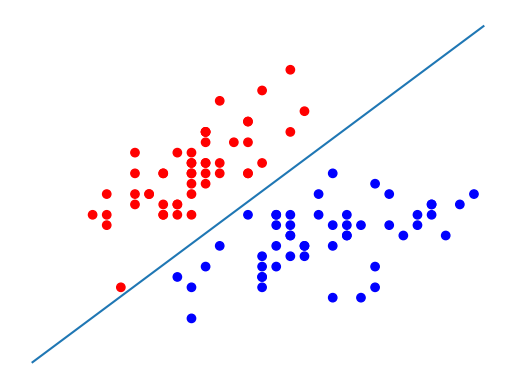

In [6]:
from matplotlib import pyplot as plt

# Plot the points and highlight classes with different colors
color = ["red" if c == 0 else "blue" for c in target]
plt.scatter(features_standardized[:,0], features_standardized[:,1], c=color)

# Create hyperplane
w = svc.coef_[0]
a = -w[0] / w[1]
xx = np.linspace(-2.5, 2.5)
yy = a * xx - (svc.intercept_[0]) / w[1]

# Plot the hyperplane
plt.plot(xx, yy)
plt.axis("off")
plt.show()

In [11]:
# New observation to predict
new_observation = [[-2, 3]]

# Predict the class of the new observation
svc.predict(new_observation)


array([0])

### Managing linearly inseparable classes via convolution kernels

In [13]:
from sklearn.svm import SVC
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
import numpy as np

# Set random seed for reproducibility
np.random.seed(0)

# Create two features
features = np.random.randn(200, 2)

# Use logical XOR to create a target variable that is not linearly separable
# for linear not sepaarable data
target_xor = np.logical_xor(features[:, 0] > 0, features[:, 1] > 0)
target = np.where(target_xor, 0, 1)

# Create a model based on the support vector machine with a radial basis function kernel
svc = SVC(kernel="rbf", random_state=0, gamma=1, C=1)

# Train the classifier
model = svc.fit(features, target)

In [15]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

# Create grapch for create hyperplane and decision boundary
def plot_decision_regions(X, y, classifier):
    cmap = ListedColormap(("red", "blue"))
    xx1, xx2 = np.meshgrid(np.arange(-3, 3, 0.02), np.arange(-3, 3, 0.02))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.1, cmap=cmap)
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                    alpha=0.8, c=cmap(idx),
                    marker="+", label=cl)
        


/tmp/ipykernel_63472/3391869283.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],


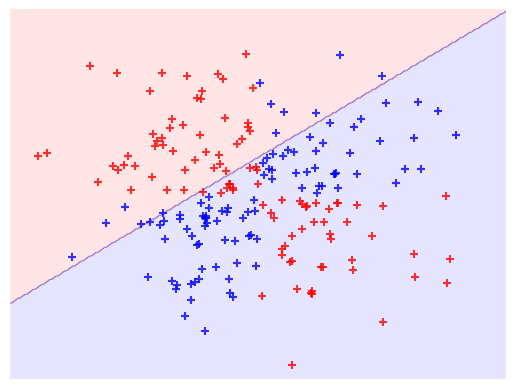

In [17]:
# create a model based on the support vector machine with a linear kernel
svc_linear = SVC(kernel="linear", random_state=0, C=1)

# Train the classifier
svc_linear.fit(features, target)
SVC(C=1, kernel="linear", random_state=0)

# Show graph for create hyperplane and decision boundary
plot_decision_regions(features, target, classifier=svc_linear)
plt.axis("off")
plt.show()


/tmp/ipykernel_63472/3391869283.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],


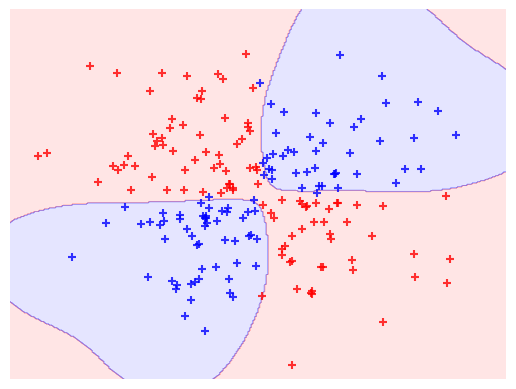

In [18]:
# Show graph for observations and hyperplane
plot_decision_regions(features, target, classifier=svc)
plt.axis("off")
plt.show()

### Creating predictive probabilities

In [20]:
from sklearn.svm import SVC
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load dataset Iris
iris = datasets.load_iris()
features = iris.data
target = iris.target

# Standardize features
scaler = StandardScaler()
features_standardized = scaler.fit_transform(features)

# Create a model based on the support vector machine with a linear kernel
svc = SVC(kernel="linear", probability=True, random_state=0)

# Train the model
model = svc.fit(features_standardized, target)

# Train a new observation
new_observation = [[.4, .4, .4, .4]]

# Predict the class of the new observation
model.predict_proba(new_observation)

/home/max/projects/machine-learning/17_support_vector_machines/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


array([[0.00541761, 0.97348825, 0.02109414]])

### Support vector machine

In [26]:
from sklearn.svm import SVC
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load iris dataset
iris = datasets.load_iris()
features = iris.data[:100, :]
target = iris.target[:100]

# Standardize features
scaler = StandardScaler()
features_standardized = scaler.fit_transform(features)

# Create a model based on the support vector machine with a linear kernel
svc = SVC(kernel="linear", random_state=0)

# Train the model
model = svc.fit(features_standardized, target)

# Display support vectors
print(f'Support vectors: \n{model.support_vectors_}')

# Display indices of support vectors
print(f'Indices of support vectors: \n{model.support_}')

# Display number of support vectors for each class
print(f'Number of support vectors for each class: \n{model.n_support_}')

Support vectors: 
[[-0.5810659   0.42196824 -0.80497402 -0.50860702]
 [-1.52079513 -1.67737625 -1.08231219 -0.86427627]
 [-0.89430898 -1.4674418   0.30437864  0.38056609]
 [-0.5810659  -1.25750735  0.09637501  0.55840072]]
Indices of support vectors: 
[23 41 57 98]
Number of support vectors for each class: 
[2 2]


### Managing unbalanced classes

In [27]:
from sklearn.svm import SVC
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load iris dataset
iris = datasets.load_iris()
features = iris.data[:100, :]
target = iris.target[:100]

# Loose balance by removing the first 40 observations of the class
features = features[40:, :]
target = target[40:]

# Create a target vector where the class is 0, the rest is 1
target = np.where((target == 0), 0, 1)

# Standardize features
scaler = StandardScaler()
features_standardized = scaler.fit_transform(features)

# Create a support vector classifier
svc = SVC(kernel="linear", class_weight="balanced", C=1.0, random_state=0)

# Train the classifier
model = svc.fit(features_standardized, target)